# PAC Kaggle Competition - BEST SUBMISSION & REPORT (A)

**INTRODUCTION**  
This notebook (Notebook A), presents the final, optimized modeling solution selected for Kaggle submission. It contains the refined preprocessing workflow, engineered features, model selection rationale, and the chosen regression model that delivered the strongest out-of-sample performance. This notebook represents the culmination of insights gained through iterative experimentation and reflects the modeling approach that best balanced accuracy, interpretability, and stability. A Written Report Summary is presented at the end of the notebook.

***Competition Overview:***  
A credit card company has provided historical data on its active customers. The data includes demographic and behavioral information on customers. Your task is to build a model to predict monthly credit card spend for individual customers.
 
Goal: Build a predictive model to estimate monthly credit card spending of individual customers based on a rich set of customer attributes, including demographics, credit behavior, transaction activity, and lifestyle indicators.

***Student Information:***  
- **Name:** Olivia (Chieh) Chou - UNI: cc5399
- **Course & Section:** APAN 5200 Section 007
- **Professor:** Andrew Assing
- **Kaggle Username:** ochou813  
- **Kaggle Display Name:** Olivia Chou

***Result:***  
- **Final Ranking (Private Leaderboard):** #7
- **Final Score:** 247.3331

## Outline
End-to-end Workflow including:

1. Data Import & Inspection
2. Data Visualization
3. Data Preprocessing
   * Feature Engineering
   * Dummy Coding
   * Train/Test Split
   * Feature Selection (Correlation Filter, Subset Selection)
   * Feature Extraction (Variance Threshold, Standardization)
4. Linear Regression Model 
5. Generate Predictions for Scoring Data

In [1]:
#Import Packages
import pandas as pd    
import numpy as np
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns
import math
from scipy.stats import pearsonr
from statsmodels.formula.api import logit
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.api import add_constant
from sklearn.pipeline import Pipeline
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.preprocessing import OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.linear_model import LogisticRegression, LassoCV, RidgeCV
from sklearn.linear_model import ElasticNet, ElasticNetCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import VotingRegressor, VotingClassifier
from sklearn.ensemble import BaggingRegressor, BaggingClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.ensemble import AdaBoostRegressor, AdaBoostClassifier
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.metrics import confusion_matrix
from sklearn.metrics import root_mean_squared_error, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

## 1. Data Import & Initial Inspection
<hr>

***Insight***

Initial inspection of the dataset revealed several important characteristics:

- The dataset contains a mix of numeric, binary, and categorical variables, confirming that preprocessing would need to handle different data types appropriately.
- Several variables such as utility_payment_count, education_level, and employment_status, contain missing values, which required imputation before modeling.
- Many categorical features (gender, marital_status, education_level, region, employment_status, card_type) contain multiple levels, making dummy encoding essential to ensure consistent model input.
- The customer_id column appears in both datasets and is non-predictive, so it needed to be retained for submission but excluded from model training.
  
These observations guided the early stages of data cleaning and preprocessing, such as dummy encoding, feature engineering, handling missing data, standardization, etc.


In [2]:
analysis = pd.read_csv("analysis_data.csv")
scoring = pd.read_csv("scoring_data.csv")

print("analysis shape:", analysis.shape)
print("scoring shape:", scoring.shape)

target_col = "monthly_spend"

analysis shape: (40000, 23)
scoring shape: (10000, 22)


In [3]:
analysis.head()

,customer_id,age,gender,marital_status,education_level,region,employment_status,owns_home,has_auto_loan,annual_income,...,card_type,num_transactions,avg_transaction_value,online_shopping_freq,reward_points_balance,travel_frequency,utility_payment_count,num_children,num_credit_cards,monthly_spend
0,75570383,77,female,married,high school,northeast,unemployed,1,0,56000.116893,...,standard,14,46.144967,8.0,6325.578928,3,3.0,1,8,1682.86
1,77915507,52,male,married,high school,south,unemployed,1,1,39432.589311,...,gold,13,88.532219,7.0,5586.814175,1,1.0,2,8,2135.57
2,31958910,48,female,married,bachelors,west,unemployed,1,1,51020.949673,...,standard,9,78.304445,4.0,6250.225115,3,2.0,0,8,1540.61
3,76868487,67,female,married,high school,northeast,unemployed,1,0,76794.566399,...,standard,10,54.932667,7.0,8875.409103,3,3.0,2,8,1250.86
4,69435006,21,female,single,bachelors,west,self-employed,1,1,44386.444631,...,standard,8,18.866712,6.0,5318.021523,4,3.0,0,8,915.36


In [4]:
analysis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            40000 non-null  int64  
 1   age                    40000 non-null  int64  
 2   gender                 40000 non-null  object 
 3   marital_status         40000 non-null  object 
 4   education_level        38801 non-null  object 
 5   region                 40000 non-null  object 
 6   employment_status      40000 non-null  object 
 7   owns_home              40000 non-null  int64  
 8   has_auto_loan          40000 non-null  int64  
 9   annual_income          40000 non-null  float64
 10  credit_score           40000 non-null  float64
 11  credit_limit           40000 non-null  float64
 12  tenure                 40000 non-null  int64  
 13  card_type              40000 non-null  object 
 14  num_transactions       40000 non-null  int64  
 15  av

In [5]:
scoring.head()

,customer_id,age,gender,marital_status,education_level,region,employment_status,owns_home,has_auto_loan,annual_income,...,tenure,card_type,num_transactions,avg_transaction_value,online_shopping_freq,reward_points_balance,travel_frequency,utility_payment_count,num_children,num_credit_cards
0,20451981,68,female,married,bachelors,west,self-employed,1,0,28736.958529,...,17,standard,6,32.444032,6.0,4360.785803,3,5.0,2,8
1,23251656,37,male,married,high school,northeast,student,0,1,177014.762457,...,14,platinum,17,30.655429,18.0,18790.889746,7,7.0,3,8
2,64082260,65,female,married,bachelors,northeast,self-employed,0,0,51625.522861,...,1,standard,9,36.063881,5.0,5625.669555,5,1.0,1,8
3,82505923,33,female,married,bachelors,northeast,self-employed,0,1,62667.564975,...,2,gold,12,28.833727,11.0,6752.725039,1,4.0,3,8
4,89981994,23,male,single,bachelors,midwest,self-employed,1,0,84996.492293,...,7,gold,15,12.361809,7.0,9154.342800,6,0.0,0,8


In [6]:
scoring.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            10000 non-null  int64  
 1   age                    10000 non-null  int64  
 2   gender                 10000 non-null  object 
 3   marital_status         10000 non-null  object 
 4   education_level        9699 non-null   object 
 5   region                 10000 non-null  object 
 6   employment_status      10000 non-null  object 
 7   owns_home              10000 non-null  int64  
 8   has_auto_loan          10000 non-null  int64  
 9   annual_income          10000 non-null  float64
 10  credit_score           10000 non-null  float64
 11  credit_limit           10000 non-null  float64
 12  tenure                 10000 non-null  int64  
 13  card_type              10000 non-null  object 
 14  num_transactions       10000 non-null  int64  
 15  avg

## 2. Initial Data Visualization
This section explores the dataset using visual tools to understand distributions, relationships, and potential modeling challenges.  
These visualizations helped form early hypotheses about which variables may be most predictive of monthly spend.

<hr>

### 2.1 Histogram

***Insight:***

- All 4 key numeric variables exhibit strong right-skewness, indicating the presence of high-value outliers and a long-tail customer distribution.
- The wide differences in variance across variables highlight the importance of applying standard scaling prior to modeling.
- The uneven distributions also suggest that engineered ratios and interaction terms may help capture meaningful behavioral differences that raw features alone cannot fully express.

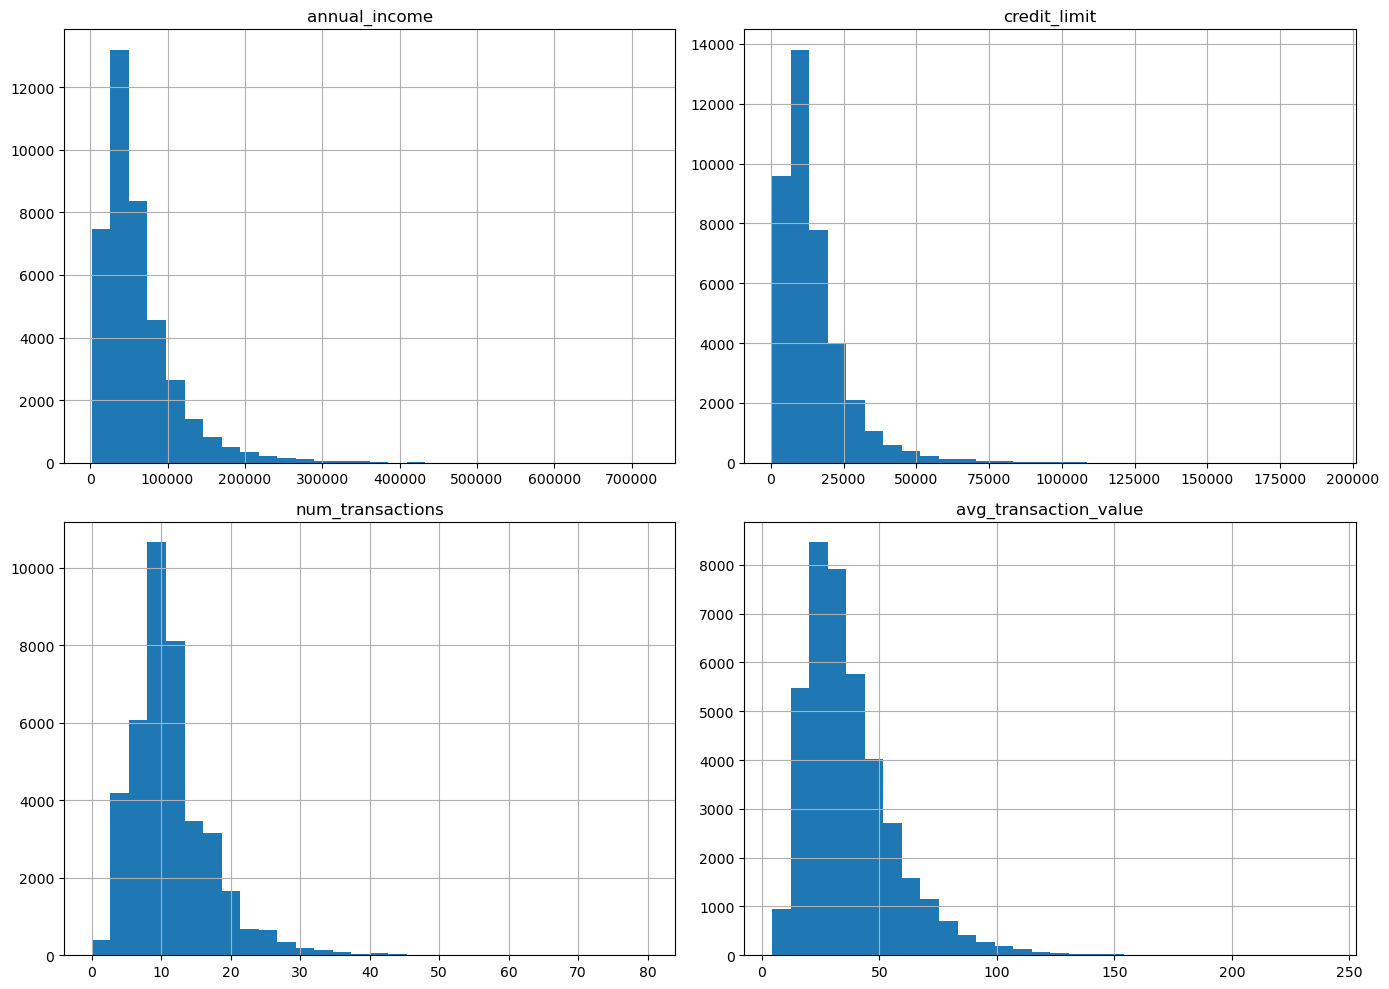

In [7]:
# Histograms of key numeric variables
numeric_cols = [
    "annual_income", "credit_limit", "num_transactions",
    "avg_transaction_value"
]

analysis[numeric_cols].hist(bins=30, figsize=(14, 10))
plt.tight_layout()
plt.show()

<hr>

### 2.2 Scatter Plot

***Insight***

- Across all scatterplots, monthly spend generally increases with stronger financial capability and engagement behaviors.
- Most customers cluster tightly in the lower-left region: low spend paired with lower income, fewer transactions, or lower credit limits  while high spenders are relatively sparse and widely dispersed.
- The overall structure resembles a funnel-shaped pattern (variance increasing with higher predictor values), indicating the need for standardization and feature transformations.

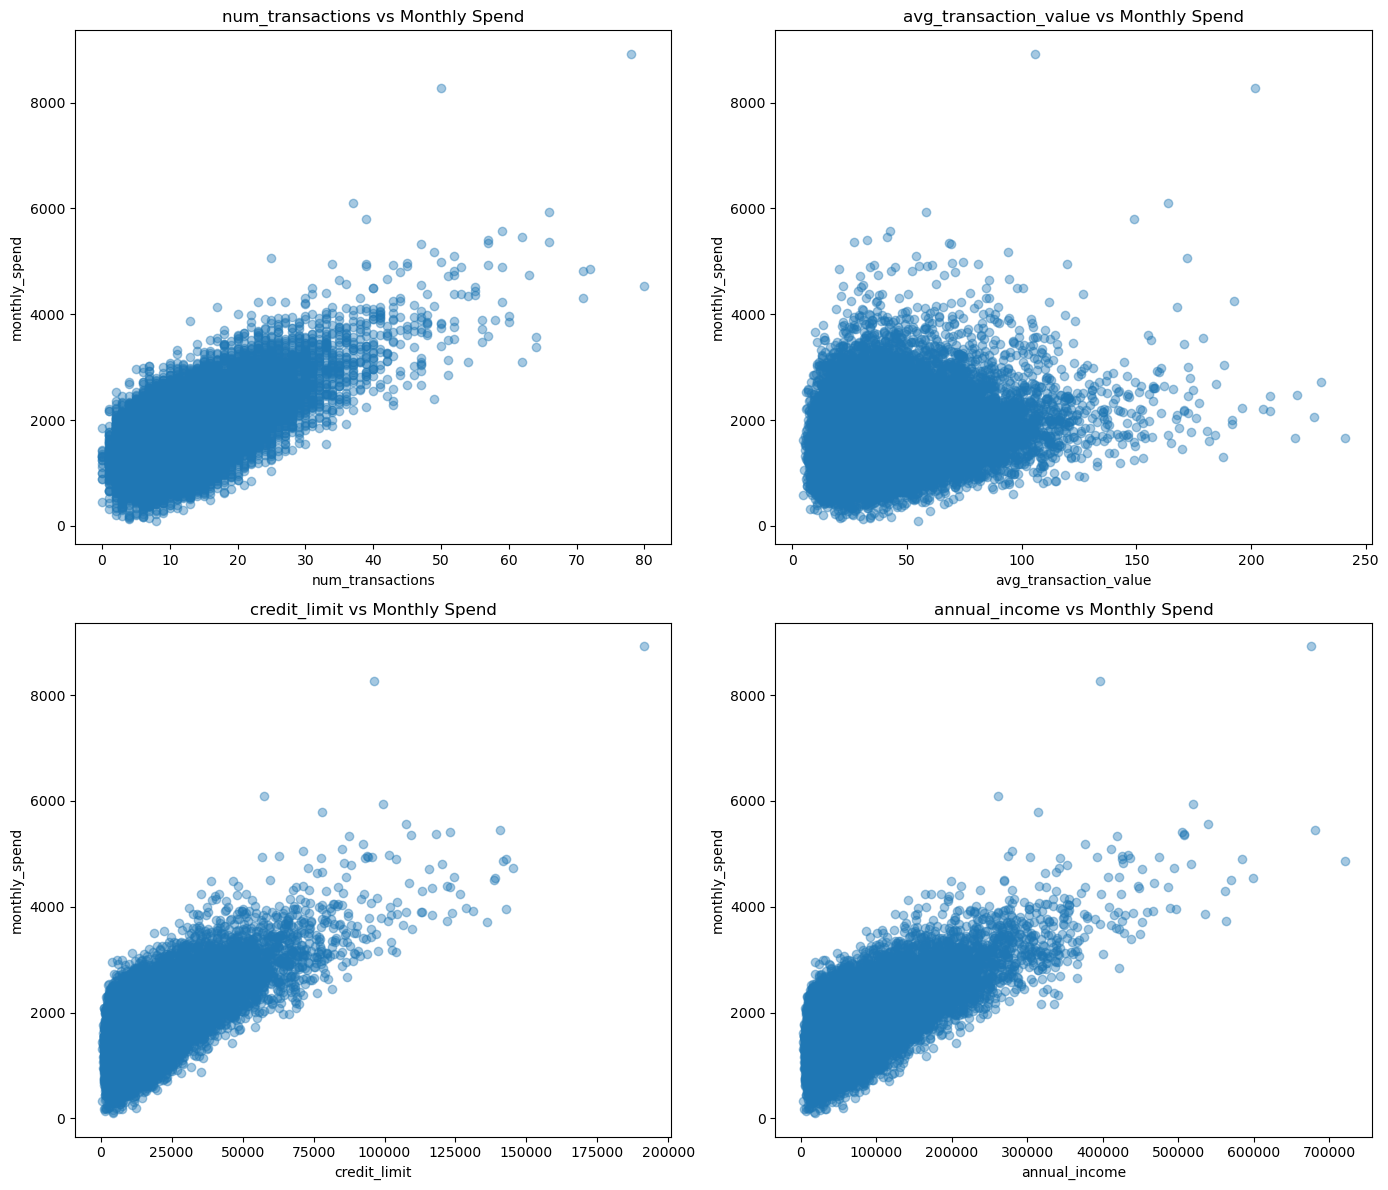

In [8]:
# Important predictors vs spend
scatter_features = [
    "num_transactions", "avg_transaction_value",
    "credit_limit", "annual_income"
]

plt.figure(figsize=(14, 12))
for i, col in enumerate(scatter_features):
    plt.subplot(2, 2, i+1)
    plt.scatter(analysis[col], analysis[target_col], alpha=0.4)
    plt.xlabel(col)
    plt.ylabel("monthly_spend")
    plt.title(f"{col} vs Monthly Spend")

plt.tight_layout()
plt.show()

<hr>

### 2.4 Correlation Heat Map

***Insight***
- Annual income, credit limit, average transaction value, and reward points balance show the strongest correlations with monly spend.
- The heatmap reveals no severe multicollinearity, meaning features contribute distinct information—supporting the use of linear modeling and validating the effectiveness of feature selection methods like SFS.

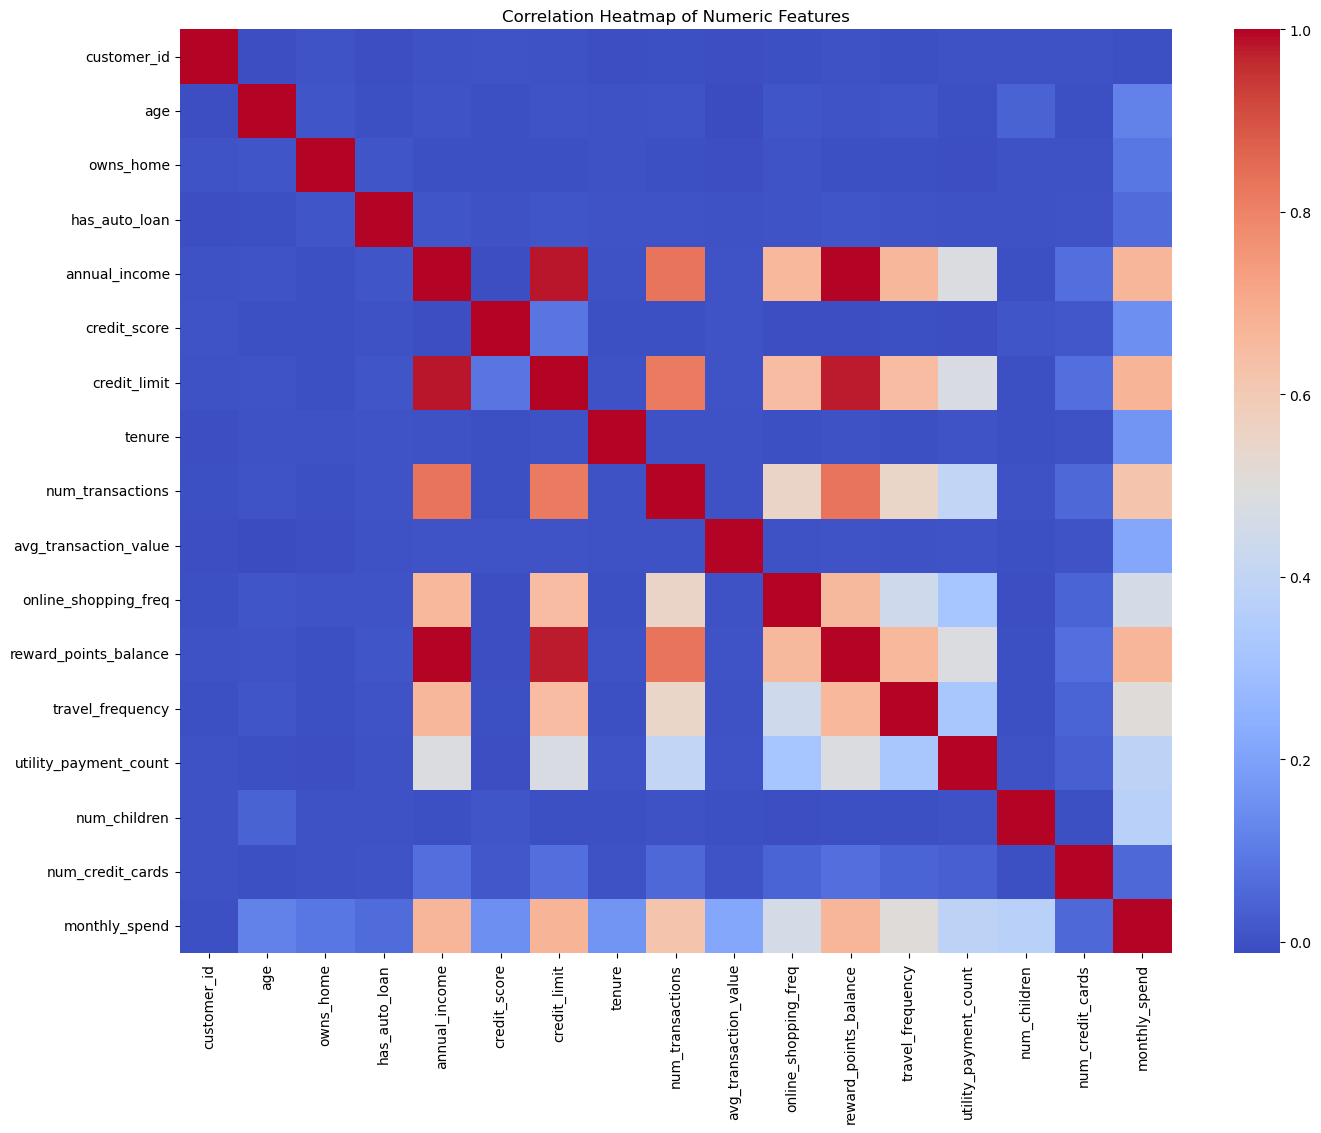

In [9]:
plt.figure(figsize=(16, 12))
corr_matrix = analysis.corr(numeric_only=True)
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

## 3. Data Preprocessing
<hr>

### 3.1 Feature Engineering
Creating more meaningful behavioral and financial signals from the raw inputs

**Purpose**
- Feature engineering increases the signal available to the model and helps uncover relationships that are not directly expressed in the original dataset.
- I created a number of derived features that aimed to capture spending capacity, credit utilization behavior, and customer engagement with the card.

**Insight & helpful engineered features**

- Ratios such as **transactions-to-limit**, **limit-to-income**, and **estimated-spend-to-income** helped control for scale differences across customers.
- Interaction terms (EX: income × transactions) captured the relationship between financial capacity and card activity.
- Polynomial terms (EX: income²) provided a way to model curvature within linear models.
- Binning credit score into categories reduced noise and helped with nonlinear scoring patterns.

**Missteps: Engineered features that did not help**

- Higher-order polynomial expansions added noise and multicollinearity without improving performance.
- Some interaction combinations resulted in sparse or uninformative columns and were later dropped during feature selection.
- Behavioral ratios involving very low activity users were unstable and required imputation or removal.

These iterations clarified which transformed variables were genuinely helpful versus which were unnecessarily complex.

In [10]:
def add_features(df):
    df = df.copy()
    
    # Avoid division by zero
    num_cards = df["num_credit_cards"].replace(0, np.nan)
    num_trans = df["num_transactions"].replace(0, np.nan)
    tenure = df["tenure"].replace(0, np.nan)
    
    # Basic FE
    df["estimated_spend"] = df["num_transactions"] * df["avg_transaction_value"]
    df["income_per_card"] = df["annual_income"] / num_cards
    df["limit_per_card"] = df["credit_limit"] / num_cards
    df["reward_points_per_year"] = df["reward_points_balance"] / tenure
    
    # Ratios
    df["transactions_to_limit"] = df["num_transactions"] / df["credit_limit"]
    df["avg_trans_to_limit"] = df["avg_transaction_value"] / df["credit_limit"]
    df["est_spend_to_limit"] = df["estimated_spend"] / df["credit_limit"]
    df["est_spend_to_income"] = df["estimated_spend"] / df["annual_income"]
    df["limit_to_income"] = df["credit_limit"] / df["annual_income"]
    
    # Behavioral ratios
    df["online_ratio"] = df["online_shopping_freq"] / num_trans
    df["util_pay_ratio"] = df["utility_payment_count"] / num_trans
    df["travel_ratio"] = df["travel_frequency"] / num_trans
    
    # Nonlinear interactions
    df["income_x_transactions"] = df["annual_income"] * df["num_transactions"]
    df["limit_x_transactions"] = df["credit_limit"] * df["num_transactions"]
    df["limit_x_avg_trans"] = df["credit_limit"] * df["avg_transaction_value"]

    # Polynomial terms
    df["income_sq"] = df["annual_income"] ** 2
    df["transactions_sq"] = df["num_transactions"] ** 2
    df["limit_sq"] = df["credit_limit"] ** 2
    
    # Credit score binning
    df["credit_score_bin"] = pd.cut(
        df["credit_score"],
        bins=[300, 580, 670, 740, 800, 850],
        labels=["poor","fair","good","very_good","excellent"]
    )
    
    return df

analysis = add_features(analysis)
scoring  = add_features(scoring)

In [11]:
analysis = analysis.dropna(subset=[target_col])

y = analysis[target_col].values
analysis_features = analysis.drop(columns=[target_col, "customer_id"])
scoring_features  = scoring.drop(columns=["customer_id"])

<HR>

### 3.2 Dummy Coding & Combined Encoding
Ensuring Consistent Categorical Representation

**Purpose**  
Convert categorical variables into numerical format using one-hot encoding, and ensure that training and scoring datasets share an identical feature structure.

**Insight**
- Encoding categories on the combined dataset prevented mismatches in dummy columns 
- Using drop_first=True avoided multicollinearity in linear models while retaining interpretability.
- Dummy coding significantly expanded the feature space, making the subsequent feature selection steps critical for identifying the strongest predictors.

In [12]:
combined = pd.concat([analysis_features, scoring_features], axis=0)
combined_dummies = pd.get_dummies(combined, drop_first=True)

combined_dummies = combined_dummies.loc[:, ~combined_dummies.columns.duplicated()]

X_all     = combined_dummies.iloc[:len(analysis)].copy()
X_scoring = combined_dummies.iloc[len(analysis):].copy()

<HR>

### 3.3   Train/Test Split
Partition the dataset into training and testing subsets to evaluate the model’s ability to generalize to unseen data.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.20, random_state=42)

<hr>

### 3.4 Feature Selection 
Identifying the Most Predictive Subset of Features

**Purpose**
- Reduce dimensionality, eliminate noise, and isolate the predictors that contribute meaningful signal to the model.
- The dataset contained a large number of raw and engineered predictors, making feature selection essential.

**Approaches that worked best in final submission** 

1. Correlation Filter
2. Forward Selection - Sequential Feature Selection (SFS)

**Missteps: Other approaches attempted but not retained (resulted in larger RMSEs)**  
*(These efforts are shown in the other submitted python notebook)*
- Backward selection
- Stepwise selection
- Shrinkage method
- Dimension reduction (PCA)

**Insight**  

- Feature selection was most effective when it balanced interpretability, computational efficiency, and model stability.  
- The combination of correlation filtering + forward SFS provided the most reliable predictor set for linear regression.

**Key Takeaway**
> Feature quality matters more than feature quantity.

---
#### 3.4.1 Correlation Filter
Filter Methods: Keep predictors that are relevant but not redundant.  
Identify predictors that exhibit a meaningful linear relationship with the target while removing low-signal or redundant features.

**Insight**
- Sorting predictors by absolute correlation helped surface strong behavioral and financial indicators.
- This step also reduced early noise among engineered features with weak or diffuse relationships to spend.
- Feeding correlation-filtered predictors into SFS improved both efficiency and stability.

In [14]:
temp = X_train.copy()
temp[target_col] = y_train

corr = temp.corr(numeric_only=True)[target_col].drop(target_col)
corr_sorted = corr.abs().sort_values(ascending=False)

top_k = 120
selected_by_corr = corr_sorted.head(top_k).index.tolist()

print(f"\nTop {top_k} features by correlation selected.")

X_train_sel   = X_train[selected_by_corr].copy()
X_test_sel    = X_test[selected_by_corr].copy()
X_all_sel     = X_all[selected_by_corr].copy()
X_scoring_sel = X_scoring[selected_by_corr].copy()


Top 120 features by correlation selected.


#### 3.4.2 Median Inpute

Several engineered ratios and behavioral features contained missing values Median imputation resolved these gaps without distorting the underlying distribution.

- Filling missing values before scaling and model fitting ensures numerical stability and prevents downstream errors.

- After imputation, all datasets contained zero remaining missing values, confirming a fully usable feature matrix.

In [15]:
medians_sel = X_train_sel.median()
X_train_sel   = X_train_sel.fillna(medians_sel)
X_test_sel    = X_test_sel.fillna(medians_sel)
X_all_sel     = X_all_sel.fillna(medians_sel)
X_scoring_sel = X_scoring_sel.fillna(medians_sel)

print("NaNs in X_train_sel after median fill:", X_train_sel.isna().sum().sum())

NaNs in X_train_sel after median fill: 0


#### 3.4.3 Subset Selection
Subset Selection: Identify a subset of p predictors that are related to the outcome.  
Here, I used Sequential Feature Selection (SFS) to perform forward selection  

**Insight**
- Forward selection consistently outperformed backward and stepwise alternatives in both stability and generalization.
- SFS also implicitly filtered out noisy engineered ratios and unstable polynomial interactions.


In [16]:
base_lr = LinearRegression()

sfs = SFS(
    base_lr,
    k_features=30,
    forward=True,
    floating=False,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1
)

sfs.fit(X_train_sel.values, y_train)

selected_idx = list(sfs.k_feature_idx_)
selected_cols = list(X_train_sel.columns[selected_idx])

print("Selected features:", selected_cols)

X_train_fs = X_train_sel[selected_cols].copy()
X_test_fs  = X_test_sel[selected_cols].copy()
X_all_fs   = X_all_sel[selected_cols].copy()
X_scoring_fs = X_scoring_sel[selected_cols].copy()

Selected features: ['credit_limit', 'annual_income', 'reward_points_balance', 'limit_x_avg_trans', 'estimated_spend', 'limit_sq', 'travel_frequency', 'card_type_platinum', 'online_shopping_freq', 'card_type_standard', 'utility_payment_count', 'num_children', 'transactions_to_limit', 'marital_status_single', 'tenure', 'credit_score', 'employment_status_self-employed', 'credit_score_bin_fair', 'employment_status_student', 'owns_home', 'employment_status_unemployed', 'has_auto_loan', 'num_credit_cards', 'est_spend_to_income', 'education_level_high school', 'gender_male', 'education_level_graduate', 'region_west', 'region_south', 'region_northeast']


### 3.5 Feature Extraction
Transforming Numeric Values

**Purpose & Insight**  
- Feature extraction ensures that the selected predictors are informative, stable, and numerically well-behaved before fitting the model. 
- After feature engineering and selection, the remaining steps focused on removing redundant predictors and placing all variables onto a comparable scale.

**Misstep**  
Alternative normalization approaches (min-max, mean-centering) were tested, but StandardScaler consistently delivered the strongest RMSE.

**Key Takeaway**
>The combination of Variance Threshold + Standard Scaling creates a more stable feature matrix, especially after heavy feature engineering.

#### 3.5.1 Variance Threshold

**Purpose**  
Remove features with zero or near-zero variance, since predictors that barely change across customers provide no meaningful signal for regression.

**Insight**
- Several engineered ratio and interaction variables had little or no variability after filtering, meaning they did not meaningfully differentiate customers.
- Removing these low-variance columns reduced noise and helped stabilize downstream model training.
- This step also simplified the feature space before applying standardization.

In [17]:
vt = VarianceThreshold(threshold=0.0)
vt.fit(X_train_fs)

X_train_var = vt.transform(X_train_fs)
X_test_var  = vt.transform(X_test_fs)
X_all_var   = vt.transform(X_all_fs)
X_scoring_var = vt.transform(X_scoring_fs)
print("Shape after VarianceThreshold:", X_train_var.shape)

Shape after VarianceThreshold: (32000, 30)


#### 3.5.2 Standardization
**Purpose**  
Transform all numeric predictors to a consistent scale

**Insight**
- Scaling was essential because predictors such as annual income, credit limit, and interaction terms operate on very different numerical ranges.
- Models like Linear Regression, Ridge, Lasso, and ElasticNet benefit directly from standardized inputs, ensuring coefficients are comparable and gradients behave well.

In [18]:
scaler = StandardScaler()
scaler.fit(X_train_var)

X_train_pre = scaler.transform(X_train_var)
X_test_pre  = scaler.transform(X_test_var)
X_all_pre   = scaler.transform(X_all_var)
X_scoring_pre = scaler.transform(X_scoring_var)

print("Shape after StandardScaler:", X_train_pre.shape)

Shape after StandardScaler: (32000, 30)


## 4. Linear Regression Model (Final Candidate)
<hr>

**Analysis Techniques Explored**


My initial trategy was starting broad and testing multiple machine learning models before committing to any single approach (shown in the other submitted notebook).

**Models Explored**

- Linear Regression  
- Ridge and Lasso Regression  
- Decision Trees  
- Random Forests  
- Bagging Regressors  
- Gradient Boosting Regressors
- Adaboost Regressor

**Observations from model experiments & missteps**

- Increasing model complexity did **not** improve predictive accuracy.
- Tree-based models (DecisionTree_simple and DecisionTree_pruned) produced the highest RMSE values, confirming that simple splits could not capture the complexity of spending behavior in this dataset.
- Ensemble tree models (Bagging, AdaBoost) improved stability but still resulted in higher test RMSE than linear approaches, indicating that variance reduction alone was not sufficient.
- Gradient Boosting and Random Forest outperformed other tree-based methods, but their gains came with substantial overfitting—very low train RMSE but higher test RMSE—highlighting limited generalization.
- Linear models produced the best and most stable test RMSE across multiple feature subsets.

These results suggested that the underlying relationships in the data were largely linear, and that simpler models generalized better than more complex ones.

**Shift in Strategy**  
After seeing consistent patterns across many experiments, I shifted my strategy:
- Instead of chasing complexity, I invested in **cleaner features, better preprocessing, and careful selection**.  
- The best-performing approach was ultimately the **simplest one: Linear Regression**.

**Key Takeaway**
> More complex does not mean more accurate, especially when the data has strong underlying linear structure

In [19]:
lr = LinearRegression()
lr.fit(X_train_fs, y_train)

lr_train_pred = lr.predict(X_train_fs)
lr_test_pred  = lr.predict(X_test_fs)

lr_train_rmse = root_mean_squared_error(y_train, lr_train_pred)
lr_test_rmse  = root_mean_squared_error(y_test, lr_test_pred)

print("\n=== LINEAR REGRESSION RESULTS ===")
print("Train RMSE:", lr_train_rmse)
print("Test RMSE :", lr_test_rmse)


=== LINEAR REGRESSION RESULTS ===
Train RMSE: 250.11772258563522
Test RMSE : 249.21983559799128


In [20]:
# Retrain Model on Full Training Data
lr.fit(X_all_pre, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## 5. Generate Predictions for Scoring Dataset
<hr>

In [21]:
scoring_preds = lr.predict(X_scoring_pre)

In [22]:
submission = pd.DataFrame({
    "customer_id": scoring["customer_id"],
    "monthly_spend": scoring_preds
})

submission.to_csv("submission17.csv", index=False)
print(submission.head())

   customer_id  monthly_spend
0     20451981    1861.006102
1     23251656    2738.599049
2     64082260    1445.686990
3     82505923    2009.351702
4     89981994    1418.337082


<hr>

# Written Report Summary — Final Modeling Workflow

## Insights From Exploring the Data

The core design of this final workflow was guided by early analytical findings:

- **Strong right-skewness** across key variables such as income, credit limit, lifetime transaction counts, and merchant activity signaled the presence of long-tail customer behavior. This highlighted the need for median-based imputation and robust scaling.
- Scatterplots revealed **consistent, monotonic relationships** between monthly spend and behavior-driven features. This motivated engineered ratios to better account for intensity, frequency, and proportional behavior.
- Correlation patterns showed that financial and behavioral attributes grouped into **natural clusters**, suggesting redundancy but not in a form that PCA could effectively capture. This insight directly shaped the decision to favor feature engineering over PCA.
- The structure of the dataset (mixed numeric, categorical, and high-cardinality features) reaffirmed the importance of a standardized preprocessing pipeline to ensure stability across different model types.

These observations formed the foundation of the notebook's preprocessing and modeling strategy.

---

## Data Cleaning & Preprocessing

High-quality data preparation was essential to obtaining a stable and interpretable model

### 1. Median Imputation
Median imputation was selected to address missing values in skewed behavioral and financial variables.  
- It preserved robustness to outliers.  
- It ensured all engineered ratios and numeric predictors remained valid.  
- It avoided distortions introduced by mean imputation in long-tailed distributions.

### 2. Dummy Encoding
Categorical variables such as occupation, education, and customer segment required dummy encoding.  
- Drop-first encoding prevented multicollinearity inflation.  
- Ensured compatibility with linear models, which require numeric-only inputs.  
- Resulted in a stable and interpretable feature matrix used in the final regression model.

### 3. Feature Engineering
Feature engineering was one of the most consequential contributors to model performance.
Engineered features included:  
- **Behavioral ratios** (e.g., spend per transaction, activity intensity)  
- **Proportional relationships** (e.g., share of online vs. offline activity)  
- **Interaction terms** linking financial capacity (credit limit, income) to activity patterns

### 4. Correlation Filter - Feature Selection
A correlation-based filter was applied to identify and remove predictors exhibiting excessively high pairwise correlations.
- High correlations signal *redundancy*, meaning multiple features convey the same information.  
- Removing redundant variables reduces multicollinearity, stabilizing coefficient estimates in linear models.  
- This step improved interpretability by ensuring each retained predictor contributed unique behavioral or financial information.  

### 5. Subset (Forward) Selection - Feature Selection
Forward selection was explored to determine a subset of predictors that offered the strongest incremental improvements in model performance.
- The process begins with no predictors and adds variables one at a time based on RMSE improvement.  
- Helps identify predictors that meaningfully contribute signal beyond what existing features capture.  
- Highlights diminishing returns when additional features provide only marginal or noisy improvements.  

### 6. Variance Threshold - Feature Extraction
A variance filter was applied to identify features with extremely low or near-zero variance—often indicators, flags, or categorical dummies with minimal variability.
- Low-variance features do not meaningfully distinguish between customers.  
- They introduce noise and unnecessary dimensionality without contributing predictive signal.  
- Removing them ensures the model focuses only on features with meaningful variability.  

### 7. Standardization - Feature Extraction
StandardScaler was applied after imputation and encoding to normalize variance.  
- Necessary due to extremely different scales (e.g., transaction counts in thousands vs. binary indicators).  
- Improved coefficient interpretability and model optimization.  
- Beneficial for any model using distance-based assumptions, though the final model was linear.

These derived metrics better captured customer heterogeneity and delivered meaningful predictive signal that PCA-based components failed to preserve.

---

## Modeling Strategy and Final Model Selection

A wide range of models was evaluated during the full development process. Notebook A contains only the refined steps leading to the final chosen model:

### Evaluation Across Model Families
- **Linear Regression** consistently provided strong baseline performance with low variance and stable generalization.
- **Lasso and Ridge** were tested to address potential multicollinearity, but did not significantly outperform OLS, showing the engineered feature space was already well-behaved.
- **Tree-based models** (Decision Tree, Random Forest, Gradient Boosting, etc) were tested separately in exploratory work but demonstrated higher RMSE, overfitting, and loss of interpretability.
- **PCA-based regression**, investigated in Notebook B, consistently underperformed due to loss of behavioral meaning.

### Final Model Choice
The final model used for submission was:

**Ordinary Least Squares Linear Regression with engineered features**

This model was selected because it offered:  
- The **lowest and most stable test RMSE** across all experiments  
- High interpretability of coefficients  
- Robust generalization due to well-prepared features  
- Minimal risk of overfitting compared to nonlinear models  

---

## Why This Workflow Was Successful

Several strategic decisions drove the success of the final approach:

- **Feature engineering outperformed dimensionality reduction**, preserving meaningful behavioral structure that PCA could not.
- **Scaling and median imputation created a numerically stable dataset**, preventing distorted relationships and improving model reliability.
- The spending behavior exhibited **mostly linear relationships**, making a simple regression model both appropriate and optimal.
- Avoiding unnecessary complexity reduced variance, improved interpretability, and allowed the model to generalize well.

In summary, aligning the modeling strategy with the dataset's underlying structure produced the most effective results.

---

## Overall Learnings from the Project
This project reinforced several important principles of end-to-end modeling:

>1. Strong predictive performance depends more on **data preparation**, **reasonable feature engineering**, and **careful feature selection** than on model complexity.
>
>2. Starting broad with multiple models helps build intuition for the problem structure.
>
>3. Iterative experimentation and testing multiple preprocessing combinations, feature subsets, and model families helped reveal structural patterns in the data.
>
>4. Failed experiments were still valuable as they clarified which assumptions held and which modeling directions were not worth pursuing.
>
>5. Simpler models often generalize better when the underlying data structure is largely linear.

The final solution combines thoughtful feature engineering, principled feature selection, consistent preprocessing, and a straightforward linear regression model, resulting in a robust and interpretable prediction pipeline.